# 01 Data Understanding

This notebook orients the project around the public UCI Taiwan credit-card default dataset and the next-month default prediction task.

## Reproducibility note

These notebooks are lightweight narrative companions to the source-controlled pipeline. The canonical workflow lives in src, generated metrics and figures live under reports, and the final selected model is models/xgboost_public.pkl. The protected attribute SEX is excluded from active model training and retained only for fairness diagnostics.

In [1]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Image, Markdown

from src.utils import ROOT_DIR, REPORTS_DIR, MODELS_DIR, load_dataset_auto, load_model
from src.data_preprocessing import TARGET_COL

ROOT = ROOT_DIR
REPORTS = REPORTS_DIR
MODELS = MODELS_DIR
PROCESSED_DATA = ROOT / 'data' / 'processed' / 'uci_taiwan_credit_default_processed.csv'

pd.set_option('display.max_columns', 120)
sns.set_theme(style='whitegrid')


def load_json(path: Path):
    with open(path, 'r', encoding='utf-8') as handle:
        return json.load(handle)


def show_image_if_exists(path: Path, width: int = 900):
    if path.exists():
        display(Image(filename=str(path), width=width))
    else:
        print(f'Missing optional image: {path.relative_to(ROOT) if path.is_absolute() else path}')


def load_project_dataset():
    try:
        frame, source = load_dataset_auto()
        return frame, source
    except Exception as exc:
        if PROCESSED_DATA.exists():
            print(f'UCI loader failed; using processed local fallback. Reason: {exc}')
            return pd.read_csv(PROCESSED_DATA), PROCESSED_DATA
        raise

raw_df, DATA_SOURCE = load_project_dataset()
print('Project root:', ROOT)
print('Data source:', DATA_SOURCE)
print('Rows:', f'{len(raw_df):,}')
print('Columns:', raw_df.shape[1])

df = raw_df.copy()
display(df.head())
display(df.dtypes.rename('dtype').to_frame())

Project root: D:\PGDBA\Projects\Credit Default Risk\credit-default-xai
Data source: uci:\default_credit_card
Rows: 30,000
Columns: 38


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,Default_Flag,BillToLimitRatio_1,BillToLimitRatio_2,BillToLimitRatio_3,BillToLimitRatio_4,BillToLimitRatio_5,BillToLimitRatio_6,AvgBillToLimitRatio,AvgPaymentToBillRatio,RecentPaymentDelay,MaxPaymentDelay,NumDelayedMonths,AvgBillAmount,AvgPaymentAmount,PaymentToLimitRatio
0,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1,0.195650,0.155100,0.034450,0.000000,0.000000,0.000000,0.064200,0.037019,2,2,2,1284.000000,114.833333,0.005742
1,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1,0.022350,0.014375,0.022350,0.027267,0.028792,0.027175,0.023718,0.311916,-1,2,2,2846.166667,833.333333,0.006944
2,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0,0.324878,0.155856,0.150656,0.159233,0.166089,0.172767,0.188246,0.115141,0,0,0,16942.166667,1836.333333,0.020404
3,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0,0.939800,0.964660,0.985820,0.566280,0.579180,0.590940,0.771113,0.036396,0,0,0,38555.666667,1398.000000,0.027960
4,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0,0.172340,0.113400,0.716700,0.418800,0.382920,0.382620,0.364463,1.246958,-1,0,0,18223.166667,9841.500000,0.196830


,dtype
LIMIT_BAL,int64
SEX,int64
EDUCATION,int64
MARRIAGE,int64
AGE,int64
PAY_0,int64
PAY_2,int64
PAY_3,int64
PAY_4,int64
PAY_5,int64


## Dataset profile

The dataset contains borrower profile fields, repayment-status history, bill amounts, payments, credit limit, and the next-month default target.

,missing_values,unique_values
LIMIT_BAL,0,81
SEX,0,2
EDUCATION,0,7
MARRIAGE,0,4
AGE,0,56
PAY_0,0,11
PAY_2,0,11
PAY_3,0,11
PAY_4,0,11
PAY_5,0,10


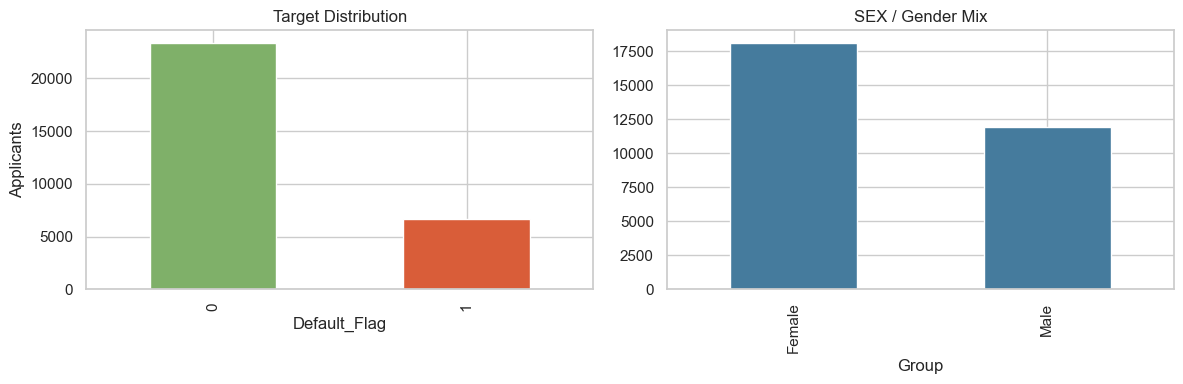

In [2]:
summary = pd.DataFrame({
    'missing_values': df.isna().sum(),
    'unique_values': df.nunique(dropna=False),
}).sort_values(by='missing_values', ascending=False)
display(summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df[TARGET_COL].value_counts().sort_index().plot(kind='bar', ax=axes[0], color=['#7fb069', '#d95d39'])
axes[0].set_title('Target Distribution')
axes[0].set_xlabel('Default_Flag')
axes[0].set_ylabel('Applicants')

if 'SEX' in df.columns:
    sex_labels = {1: 'Male', 2: 'Female'}
    df['SEX'].map(sex_labels).fillna(df['SEX'].astype(str)).value_counts().plot(kind='bar', ax=axes[1], color='#457b9d')
    axes[1].set_title('SEX / Gender Mix')
    axes[1].set_xlabel('Group')
else:
    df.select_dtypes(include='number').nunique().sort_values(ascending=False).head(10).plot(kind='bar', ax=axes[1], color='#457b9d')
    axes[1].set_title('Top Numeric Cardinalities')
plt.tight_layout()

## Takeaways

- Current project dataset: UCI Taiwan credit-card default.
- Target: Default_Flag, where 1 means next-month default.
- SEX uses the verified UCI coding 1 = Male and 2 = Female.
- SEX is not used in active model training; it is retained for fairness governance diagnostics.